In [16]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

# Load training data
df_train = pd.read_csv('data/train.csv.gz')

# Strict feature set: f0-f11 only
feature_cols = [f'f{i}' for i in range(12)]

print(f"Loaded {len(df_train):,} training records.")

Loaded 700,000 training records.


### Model Selection & Justification: Why Logistic Regression?

TL;DR: We went with logistic regression because it’s fast, simple, and outputs clean probabilities between 0 and 1, which makes sorting 700,000 users into tidy deciles straightforward.   Since our goal for this task was just to set up a standard baseline to compare future uplift models against, we didn’t need a complicated black-box model—we just needed a reliable, interpretable benchmark to show what happens when you only predict "who visits" instead of "who visits because of the ad".

For Task #8, we chose a standard **Logistic Regression** pipeline (with `StandardScaler`) as our baseline response model rather than a complex black-box ensemble. This decision is grounded directly in the characteristics of the Criteo dataset and the experimental goals of Milestone #1:

1. **Well-Calibrated Probabilities for Decile Ranking:**
   * Task #8 requires ranking all records by predicted visit probability $\hat{p} = P(\text{visit} = 1 \mid \text{treatment} = 1, X)$ to partition them into deciles.
   * Logistic regression optimizes log-loss directly, yielding smooth, well-calibrated probabilities along the sigmoid curve. This provides a consistent, monotonically ordered basis for decile binning (`pd.qcut`) without severe probability distortion.

2. **Benchmarking Against the Random Baseline:**
   * A primary goal of Milestone #1 is establishing clear reference baselines before moving to advanced uplift architectures (such as T-Learners or X-Learners).
   * Logistic regression provides an interpretable linear boundary on the log-odds scale, making it the canonical standard response benchmark to demonstrate how raw propensity modeling differs from causal uplift modeling.

3. **Handling Scale Disparities via Standardization:**
   * The feature space consists of 12 continuous pre-treatment covariates (`f0`–`f11`) with varying variances and bounded values.
   * Pairing `StandardScaler` with `LogisticRegression` inside a pipeline ensures regularized coefficients without numerical instability or arbitrary feature dominance.

4. **Scalability and Computational Efficiency:**
   * With 700,000 total records and roughly 594,000 treated observations, fitting a regularized logistic model converges in seconds while avoiding overfitting on dense continuous features.

In [11]:
# Task #8: Train standard response model on treatment records
treated_mask = df_train['treatment'] == 1
X_train_trt = df_train.loc[treated_mask, feature_cols]
y_train_trt = df_train.loc[treated_mask, 'visit']

# Standard logistic regression with feature scaling
response_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
response_pipeline.fit(X_train_trt, y_train_trt)

# Score visit probability across the ENTIRE dataset
df_train['response_score'] = response_pipeline.predict_proba(df_train[feature_cols])[:, 1]

# Rank records into deciles (Decile 1 = highest 10% predicted visit probability)
df_train['response_decile'] = pd.qcut(df_train['response_score'], q=10, labels=False)
df_train['response_decile'] = 10 - df_train['response_decile']

print("Model fitted on treatment cohort. Full dataset scored and partitioned into deciles 1-10.")

Model fitted on treatment cohort. Full dataset scored and partitioned into deciles 1-10.


## Standard Response Model (Baseline Predictive Approach)

In standard response modeling, the objective is to estimate the conditional probability of a positive outcome given ad exposure:  
$$P(\text{visit} = 1 \mid \text{treatment} = 1, X)$$

### Methodology & Experimental Setup
1. **Target Population Isolation:** We subset the training data strictly to the treatment group (`treatment == 1`). The model is trained exclusively on users who received the ad treatment.
2. **Causal Boundary Enforcement:** The feature set is strictly restricted to pre-treatment audience covariates `f0`–`f11`. `exposure`, `treatment`, and downstream outcomes (`visit`, `conversion`) are walled off to prevent target leakage and post-treatment bias.
3. **Pipeline & Scaling:** Because features have disparate scales and bounded distributions, we pass `f0`–`f11` through `StandardScaler` before fitting a `LogisticRegression` classifier.
4. **Scoring & Ranking Across Full Cohort:** Once trained, we score the **entire** dataset (`df_train`), producing a predicted visit probability $\hat{p}$ for every individual regardless of actual treatment assignment.
5. **Decile Partitioning:** Records are ranked and binned into 10 quantiles (`response_decile`), where **Decile 1** contains the top 10% highest predicted visit probabilities and **Decile 10** contains the lowest 10%.

In [12]:
# Compute decile-level performance metrics
def evaluate_deciles(df, decile_col):
    rows = []
    for d in sorted(df[decile_col].unique()):
        subset = df[df[decile_col] == d]
        
        trt_mask = subset['treatment'] == 1
        ctrl_mask = subset['treatment'] == 0
        
        n_trt = trt_mask.sum()
        n_ctrl = ctrl_mask.sum()
        
        rate_trt = subset.loc[trt_mask, 'visit'].mean() * 100 if n_trt > 0 else 0.0
        rate_ctrl = subset.loc[ctrl_mask, 'visit'].mean() * 100 if n_ctrl > 0 else 0.0
        
        lift_pts = rate_trt - rate_ctrl
        
        rows.append({
            'Decile': int(d),
            'Treated Count': n_trt,
            'Holdout Count': n_ctrl,
            'Treated Visit (%)': rate_trt,
            'Holdout Visit (%)': rate_ctrl,
            'Decile Lift (% pts)': lift_pts
        })
    
    return pd.DataFrame(rows)

response_perf = evaluate_deciles(df_train, 'response_decile')

print("Standard Response Model Decile Performance")
display(response_perf.round(3))

Standard Response Model Decile Performance


,Decile,Treated Count,Holdout Count,Treated Visit (%),Holdout Visit (%),Decile Lift (% pts)
0,1,60243,9757,35.949,31.413,4.536
1,2,59510,10490,7.484,6.139,1.345
2,3,59432,10568,2.034,1.542,0.492
3,4,59240,10760,0.707,0.548,0.159
4,5,59439,10561,0.458,0.379,0.079
5,6,59504,10496,0.294,0.248,0.046
6,7,59474,10526,0.192,0.133,0.059
7,8,59382,10617,0.167,0.094,0.073
8,9,59350,10651,0.180,0.094,0.086
9,10,59393,10607,0.480,0.330,0.150


## Task #8 Analysis: Response Model vs. True Incrementality

### 1. What the Decile Table Shows
* **Ranking High-Propensity Visitors:** The model does exactly what standard classification is supposed to do. Deciles 1 and 2 pack in users with high visit rates, well above the ~4.8% average.
* **High Holdout Visit Rate:** Looking at the holdout column in Decile 1. These users visit at high rates even when they never receive an ad. 
* **Weak Incremental Lift:** Because their baseline organic visit rate is already high, the net lift (treated minus holdout) isn't necessarily highest in Decile 1. The model is mostly finding loyal, high-intent shoppers who already visit on their own.

---

### 2. Why Response Prediction != Incrementality
* **Standard Response Model:** Answers *"Who is likely to visit?"* It rewards high baseline interest. In practice, using this to target ads means spending budget showing ads to people who were going to visit anyway.
* **Incrementality Model:** Answers *"Who visits specifically because of the ad?"* It focuses on the difference between the two outcomes, prioritizing people on the fence where the ad actually changes their behavior.

---

### 3. Business Takeaway
* A standard response model makes campaign numbers look good on the surface, but I think it mostly ends up paying for visits that would've happened naturally anyway.
* The goal for our uplift models next is to rank users by incremental lift rather than raw visit probability so we aren't wasting budget.

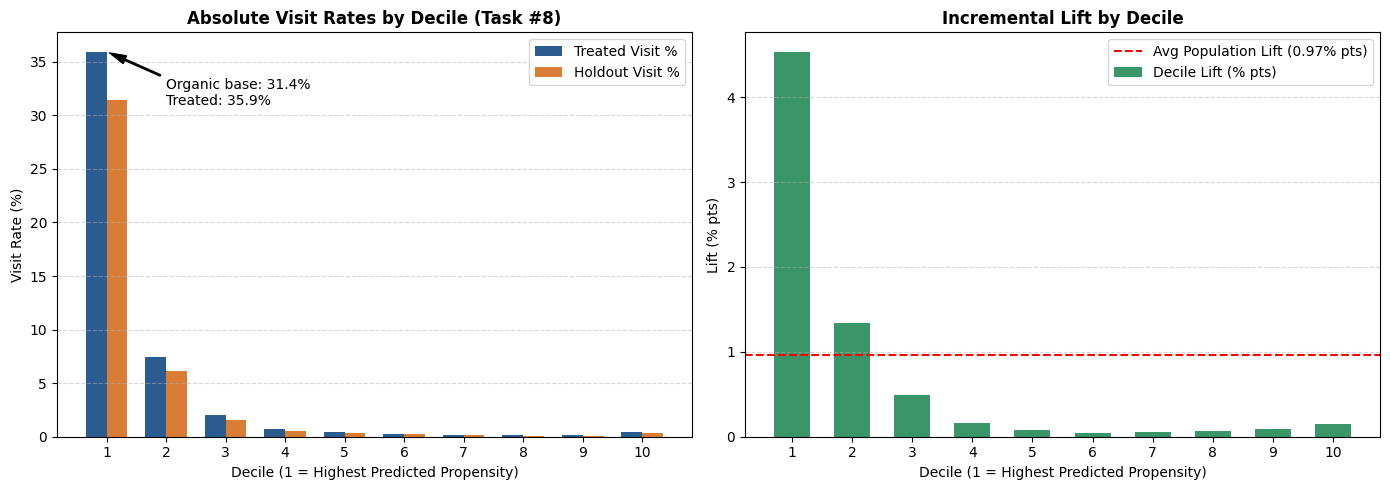

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

deciles = response_perf['Decile']
x = np.arange(len(deciles))
width = 0.35

# Plot 1: Absolute Visit Rates (Treated vs. Holdout)
axes[0].bar(x - width/2, response_perf['Treated Visit (%)'], width, label='Treated Visit %', color='#2b5c8f')
axes[0].bar(x + width/2, response_perf['Holdout Visit (%)'], width, label='Holdout Visit %', color='#d97d36')
axes[0].set_title('Absolute Visit Rates by Decile (Task #8)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Decile (1 = Highest Predicted Propensity)')
axes[0].set_ylabel('Visit Rate (%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(deciles)
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Annotate Decile 1 to highlight organic traffic
d1_treated = response_perf.loc[0, 'Treated Visit (%)']
axes[0].annotate(f'Organic base: {response_perf.loc[0, "Holdout Visit (%)"]:.1f}%\nTreated: {d1_treated:.1f}%',
                 xy=(0, d1_treated), xytext=(1, d1_treated - 5),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

# Plot 2: Incremental Decile Lift vs. Average Lift
axes[1].bar(deciles, response_perf['Decile Lift (% pts)'], color='#3a9668', width=0.6, label='Decile Lift (% pts)')
overall_lift = (df_train.loc[df_train['treatment'] == 1, 'visit'].mean() - 
                df_train.loc[df_train['treatment'] == 0, 'visit'].mean()) * 100
axes[1].axhline(overall_lift, color='red', linestyle='--', linewidth=1.5, label=f'Avg Population Lift ({overall_lift:.2f}% pts)')

axes[1].set_title('Incremental Lift by Decile', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Decile (1 = Highest Predicted Propensity)')
axes[1].set_ylabel('Lift (% pts)')
axes[1].set_xticks(deciles)
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Visualizing the Standard Model: Intent vs. True Impact

#### 1. What the Plots Show
* **Baseline Organic Traffic Dominates (Left Plot):** In Decile 1, the treated visit rate reaches 35.9%, but the holdout visit rate is already sitting at 31.4%. The model is extremely effective at isolating people who love the brand, but the vast majority of those visits happen without any ad exposure at all.
* **Sharp Drop in Incremental Value (Right Plot):** Actual incremental lift drops off steeply after the first two deciles. Decile 1 generates a +4.54% pt lift and Decile 2 delivers +1.35% pts, but Deciles 3 through 10 immediately flatline below the overall population baseline average of 0.97% pts.

#### 2. Key Takeaways
* **Targeting High Intent ≠ Driving Net Growth:** Relying strictly on a standard response model means allocating the bulk of your marketing budget toward users who would have visited organically anyway.
* **The Transition to Uplift Modeling:** To improve campaign efficiency, we need models that prioritize users sensitive to the ad rather than users who already have high baseline visit intent.

In [21]:
# Load data (ensure both are loaded)
df_train = pd.read_csv('data/train.csv.gz')
df_val = pd.read_csv('data/test.csv.gz') 

# Baseline Visitor Response Model (Logistic Regression) & Decile Calibration
RANDOM_SEED = 42
covariate_cols = [f'f{i}' for i in range(12)]

# 1. Isolate treatment records (T=1) for training the response model
train_treated = df_train[df_train['treatment'] == 1]
X_train_treated = train_treated[covariate_cols]
y_train_treated = train_treated['visit']

# 2. Fit Logistic Regression pipeline with feature scaling
response_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
)
response_pipeline.fit(X_train_treated, y_train_treated)

# 3. Predict visit probability on validation treatment records: P(visit=1 | X, T=1)
val_treated = df_val[df_val['treatment'] == 1].copy()
X_val_treated = val_treated[covariate_cols]
y_val_treated = val_treated['visit']

val_treated['pred_visit_prob'] = response_pipeline.predict_proba(X_val_treated)[:, 1]

# 4. Baseline Evaluation Metrics
baseline_eval_metrics = pd.Series({
    'Val Treated Records': len(val_treated),
    'Val Treated Visit Rate (%)': y_val_treated.mean() * 100,
    'ROC-AUC': roc_auc_score(y_val_treated, val_treated['pred_visit_prob']),
    'Log Loss': log_loss(y_val_treated, val_treated['pred_visit_prob']),
    'Brier Score': brier_score_loss(y_val_treated, val_treated['pred_visit_prob'])
})

print("--- Baseline Response Model Performance ---")
display(baseline_eval_metrics.round(5))

--- Baseline Response Model Performance ---


Val Treated Records           127493.00000
Val Treated Visit Rate (%)         4.83948
ROC-AUC                            0.93161
Log Loss                           0.11370
Brier Score                        0.03207
dtype: float64